✅ Capa Gold cargada. Registros históricos totales: 27782


,node_name,year,day_of_year,in_degree,out_degree,pagerank,betweenness,is_in_lcc,snapshot_date
0,kemal,2018,148,35,2,0.026951,0.000794,True,2018-05-28
1,minitest,2018,148,17,0,0.024772,0.000000,True,2018-05-28
2,db,2018,148,17,0,0.023859,0.000000,True,2018-05-28
3,radix,2018,148,7,0,0.018899,0.000000,True,2018-05-28
4,spec2,2018,148,18,0,0.015100,0.000000,True,2018-05-28


Agrupando crecimiento histórico del ecosistema...


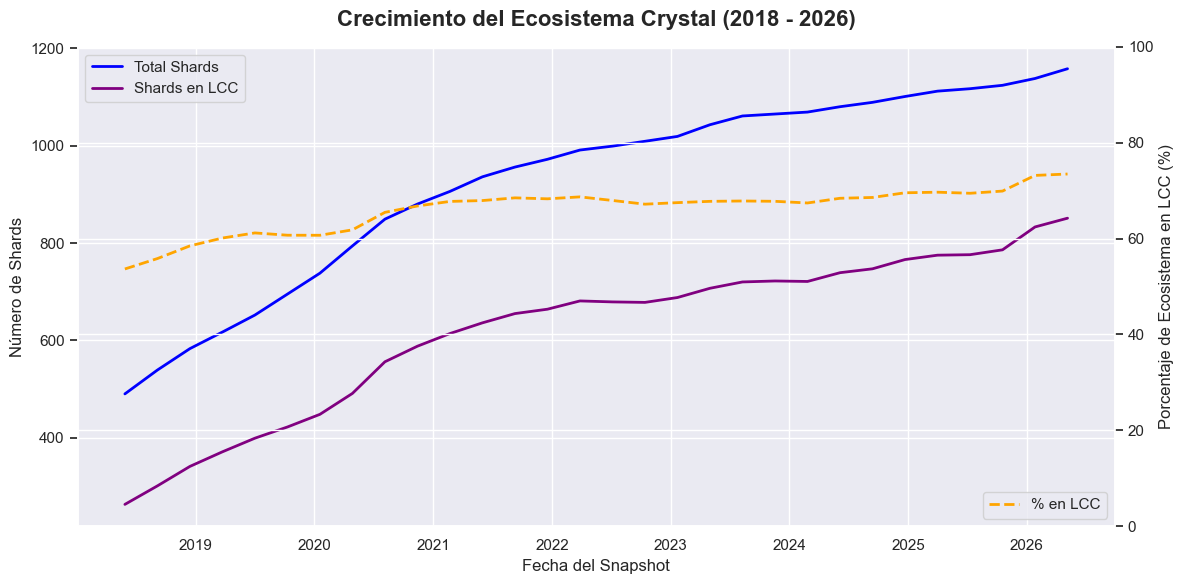

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- 1. Cargar el Master Dataset desde la capa Gold ---
gold_path = Path("data/03_gold/ecosystem_master.parquet")
df_master = pd.read_parquet(gold_path)

print(f"✅ Capa Gold cargada. Registros históricos totales: {len(df_master)}")
display(df_master.head())

# --- 2. Agrupar crecimiento histórico ---
print("Agrupando crecimiento histórico del ecosistema...")
growth_df = df_master.groupby('snapshot_date').agg(
    total_shards=('node_name', 'count'),
    lcc_size=('is_in_lcc', 'sum') 
).reset_index()

# Calcular el porcentaje del LCC
growth_df['lcc_percentage'] = (growth_df['lcc_size'] / growth_df['total_shards']) * 100

# --- 3. Gráfico de Crecimiento (Ejes Duales) ---
sns.set_theme(style="darkgrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Trazado 1: Números Absolutos (Eje Y Izquierdo)
sns.lineplot(data=growth_df, x='snapshot_date', y='total_shards', 
             ax=ax1, color='blue', linewidth=2, label='Total Shards')
sns.lineplot(data=growth_df, x='snapshot_date', y='lcc_size', 
             ax=ax1, color='purple', linewidth=2, label='Shards en LCC')

ax1.set_title("Crecimiento del Ecosistema Crystal (2018 - 2026)", fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel("Fecha del Snapshot", fontsize=12)
ax1.set_ylabel("Número de Shards", fontsize=12)
ax1.legend(loc='upper left')

# Trazado 2: Porcentaje LCC (Eje Y Derecho)
ax2 = ax1.twinx()
sns.lineplot(data=growth_df, x='snapshot_date', y='lcc_percentage', 
             ax=ax2, color='orange', linewidth=2, linestyle='--', label='% en LCC')

ax2.set_ylabel("Porcentaje de Ecosistema en LCC (%)", fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

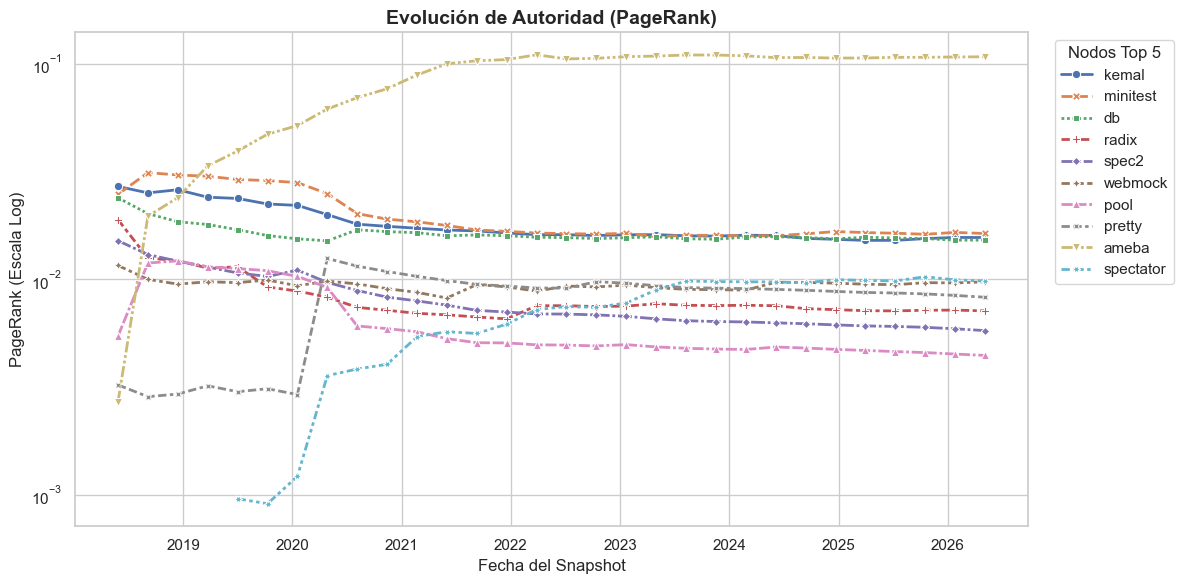

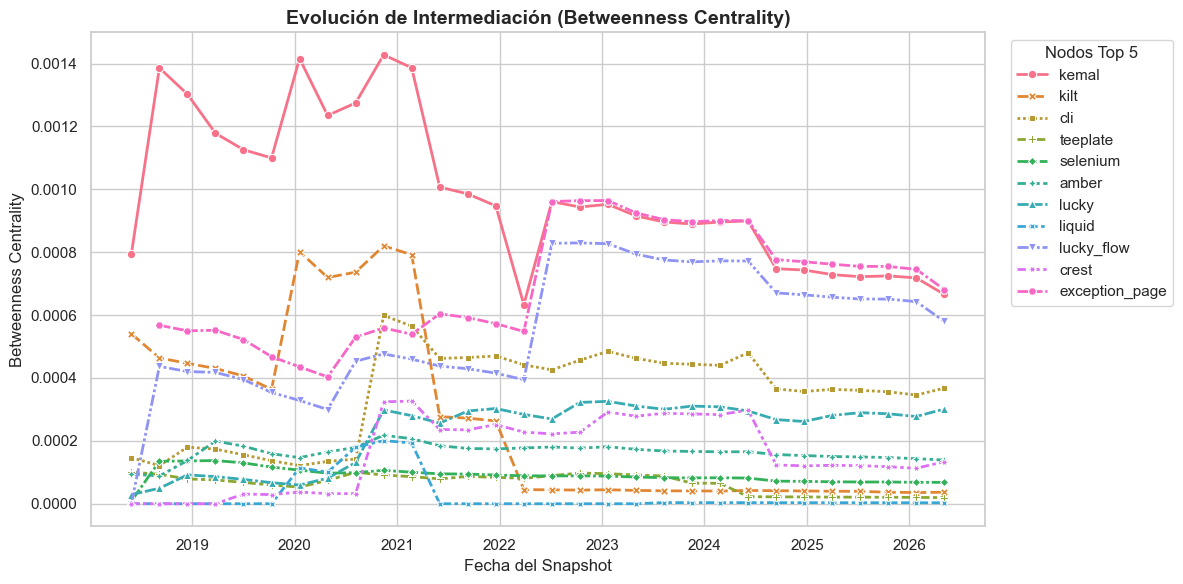

In [4]:
# --- 1. Extraer Nodos Históricos Top 5 ---
# Identifica los nodos que alguna vez estuvieron en el top 5 de ambas métricas
historical_pr_nodes = df_master.groupby('snapshot_date').apply(lambda x: x.nlargest(5, 'pagerank'))['node_name'].unique()
historical_bw_nodes = df_master.groupby('snapshot_date').apply(lambda x: x.nlargest(5, 'betweenness'))['node_name'].unique()

pr_history = df_master[df_master['node_name'].isin(historical_pr_nodes)]
bw_history = df_master[df_master['node_name'].isin(historical_bw_nodes)]

sns.set_theme(style="whitegrid")

# --- 2. Gráfico A: Evolución de PageRank (Escala Logarítmica) ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=pr_history, x='snapshot_date', y='pagerank', 
    hue='node_name', style='node_name', 
    markers=True, dashes=True, linewidth=2
)

plt.yscale('log')
plt.title("Evolución de Autoridad (PageRank)", fontsize=14, fontweight='bold')
plt.ylabel("PageRank (Escala Log)")
plt.xlabel("Fecha del Snapshot")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Nodos Top 5")

plt.tight_layout()
plt.show()

# --- 3. Gráfico B: Evolución de Betweenness ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=bw_history, x='snapshot_date', y='betweenness', 
    hue='node_name', style='node_name', 
    markers=True, dashes=True, linewidth=2
)

plt.title("Evolución de Intermediación (Betweenness Centrality)", fontsize=14, fontweight='bold')
plt.ylabel("Betweenness Centrality")
plt.xlabel("Fecha del Snapshot")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Nodos Top 5")

plt.tight_layout()
plt.show()